In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
import gurobipy as gp
from gurobipy import GRB

### 데이터 전처리

In [ ]:
# 파일 읽기(이전과 동일)
df = pd.read_csv(file_path, sep=';', encoding='latin-1', skiprows=2)

# 1) 콘솔에서 간단히 출력
print(df.head())

# 1) 모든 행·열 출력하기 (콘솔용)
pd.set_option('display.max_rows', None)    # 행 제한 해제
pd.set_option('display.max_columns', None) # 열 제한 해제

print(df)  # or print(df.to_string())

In [9]:
file_path = 'marginalpibc_2025072002.1'

In [10]:
# 파일 읽기(이전과 동일)
df = pd.read_csv(file_path, sep=';', encoding='latin-1', skiprows=2)

# 1) 콘솔에서 간단히 출력
print(df.head())

# 1) 모든 행·열 출력하기 (콘솔용)
pd.set_option('display.max_rows', None)    # 행 제한 해제
pd.set_option('display.max_columns', None) # 열 제한 해제

print(df)  # or print(df.to_string())

   2025   07    20    2  75.54  75.54.1  Unnamed: 6
0  2025  7.0  20.0  3.0  72.72    72.72         NaN
1  2025  7.0  20.0  4.0  42.23    42.23         NaN
2  2025  7.0  20.0  5.0  75.30    75.30         NaN
3  2025  7.0  20.0  6.0  75.30    75.30         NaN
4  2025  7.0  20.0  7.0  61.91    61.91         NaN
    2025   07    20     2  75.54  75.54.1  Unnamed: 6
0   2025  7.0  20.0   3.0  72.72    72.72         NaN
1   2025  7.0  20.0   4.0  42.23    42.23         NaN
2   2025  7.0  20.0   5.0  75.30    75.30         NaN
3   2025  7.0  20.0   6.0  75.30    75.30         NaN
4   2025  7.0  20.0   7.0  61.91    61.91         NaN
5   2025  7.0  20.0   8.0  35.25    35.25         NaN
6   2025  7.0  20.0   9.0  75.30    75.30         NaN
7   2025  7.0  20.0  10.0  48.33    48.33         NaN
8   2025  7.0  20.0  11.0  39.81    39.81         NaN
9   2025  7.0  20.0  12.0  23.08    23.08         NaN
10  2025  7.0  20.0  13.0  65.80    65.80         NaN
11  2025  7.0  20.0  14.0  49.92    49.9

### Supply Demand Curve and RDC

방법 1: B 블락으로 나누기

In [45]:
# # --- A) RDC 계산 함수 (생략) ---
# def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
#     rdc = []
#     for q in wf_offers:
#         resid = demand_vals - supply_vals - q
#         idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
#         for i in idx:
#             p0,p1 = price_grid[i], price_grid[i+1]
#             r0,r1 = resid[i], resid[i+1]
#             if r1!=r0:
#                 p_star = p0 - r0*(p1-p0)/(r1-r0)
#                 rdc.append((q,p_star))
#     return rdc

# # --- B) 공통 설정 ---
# days          = range(20,28)                 # 7/20~7/27
# colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# # wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# # wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

# B             = 1000                           # stepwise 블록 개수

# # stepwise 파라미터 저장용
# qini            = {}
# qmax            = {}
# lambda_da_block = {}
# orig_cp         = {}

# # --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
# fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
#                          sharex=True, sharey=True)
# axes = axes.flatten()

# # --- D) 각 Period(1~24) 에 대해 ---
# for period in range(1,25):
#     ax = axes[period-1]
#     for day, color in zip(days, colors):
#         date_str = f"202507{day:02d}"
#         fn       = f"filteredcurve_{date_str}.csv"
#         try:
#             df = pd.read_csv(fn, encoding='utf-8-sig')
#         except FileNotFoundError:
#             continue

#         # 이미 Price/Amount가 float 라고 가정
#         sub    = df[df['Time Period']==period]
#         sup    = sub[sub['GC']=='V']
#         dem    = sub[sub['GC']=='C']
#         if sup.empty or dem.empty:
#             continue

#         # 집계 & 누적
#         # 집계 & 누적
#         s_agg = sup.groupby('Price')['Amount'] \
#                     .sum().reset_index() \
#                     .sort_values('Price')
#         s_agg['Cumul'] = s_agg['Amount'].cumsum()

#         d_agg = dem.groupby('Price')['Amount'] \
#                     .sum().reset_index() \
#                     .sort_values('Price')
#         # 가격 낮을수록 누적이 커져야 하니 역순 누적
#         d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

#         # 계단 보간
#         s_f = interp1d(
#             s_agg['Price'], s_agg['Cumul'],
#             kind='previous', bounds_error=False,
#             fill_value=(0, s_agg['Cumul'].iat[-1])
#         )
#         d_f = interp1d(
#             d_agg['Price'], d_agg['Cumul'],
#             kind='previous', bounds_error=False,
#             fill_value=(d_agg['Cumul'].iat[0], 0)
#         )

#         pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
#         sv  = s_f(pg)
#         dv  = d_f(pg)
#         #Original Clearing Price 계산
#         def resid0(p): 
#             return d_f(p) - s_f(p)   # q=0
#         sol0 = root_scalar(resid0,
#                            bracket=[pg[0], pg[-1]],
#                            method='bisect')
#         orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan


#         wf_offer_grid = np.arange(
#             0,
#             s_agg['Cumul'].max() * 1.2,
#             100
#         )
        
#         # Residual Demand
#         rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
#         if not rdc_pts:
#             continue
#         qv, pv = zip(*rdc_pts)
#         qv = np.array(qv); pv = np.array(pv)

#         # ——— stepwise 근사 파라미터 계산 —————————
#         q_breaks = np.linspace(0, qv.max(), B+1)
#         delta_qs = q_breaks[1:] - q_breaks[:-1]
#         for b in range(B):
#             mid = 0.5*(q_breaks[b] + q_breaks[b+1])
#             # date_str, period, block b 를 키로 사용
#             qini   [(date_str, period, b)] = float(q_breaks[b])
#             qmax   [(date_str, period, b)] = float(delta_qs[b])
#             lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
#         # ————————————————————————————————

#         # RDC Curve만 플롯
#         # ax.plot(qv, pv, 'o-', color=color, label=date_str)
#         ax.plot(
#             qv, pv,
#             '-',                # 실선만
#             color=color,
#             label=date_str,
#             linewidth=0.8,
#             alpha=0.8
#         )

#     # subplot 제목 (예: “00:00–01:00”)
#     hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
#     ax.set_title(f"{hh1}–{hh2}", fontsize=6)
#     ax.grid(True)

# # --- E) 공통 레이블 & 레이아웃 ---
# fig.supxlabel('Quantity (MW)', fontsize=8)
# fig.supylabel('Price (€/MWh)', fontsize=8)
# fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# # 범례는 맨 마지막 축에만 표시하도록
# axes[-1].legend(title='Date', fontsize=6, loc='lower right')

# plt.tight_layout(rect=[0,0.03,1,0.95])
# plt.show()


방법 2: offer 크기만큼 stepwise

C:\Users\symply_jina\AppData\Local\Temp\ipykernel_19040\3690748265.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(title='Date', fontsize=8, loc='lower right')


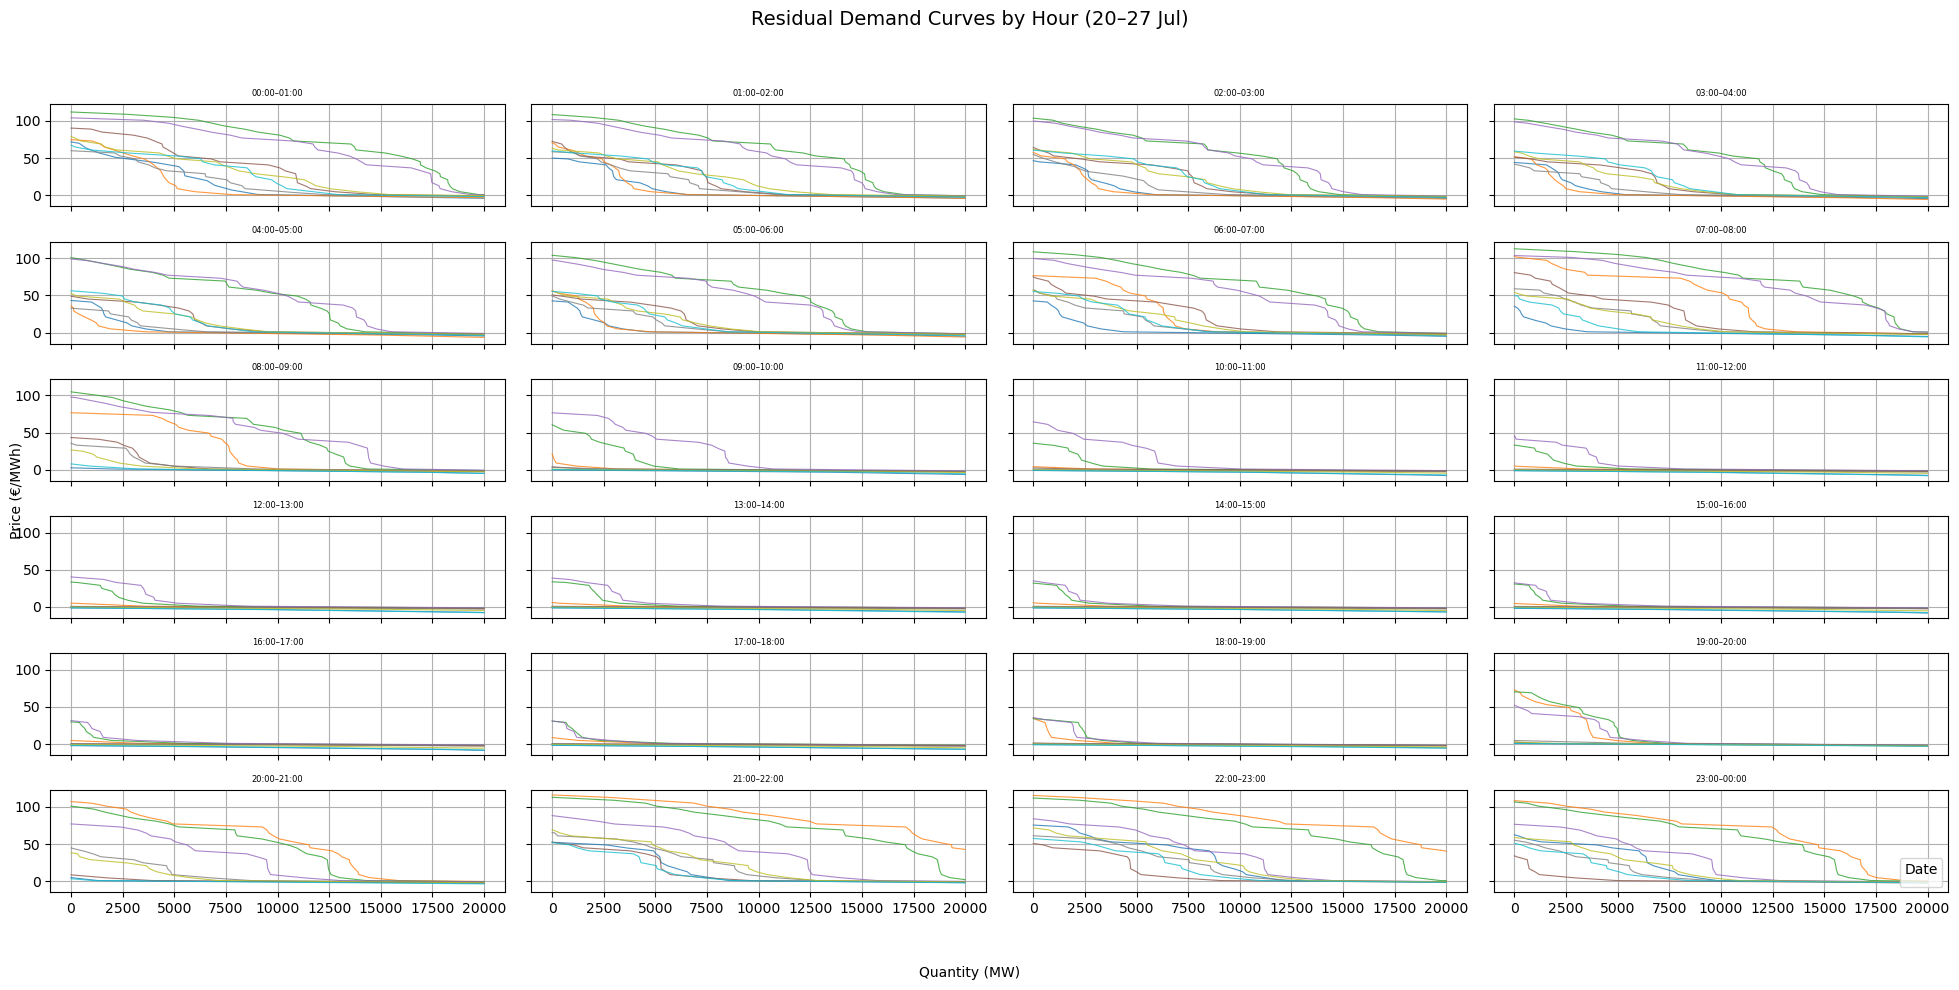

In [2]:
# ────────────────────────────────────────────────────
# A) 잔여수요 계산 함수 (선형보간)
# ────────────────────────────────────────────────────
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i],       resid[i+1]
            if r1 != r0:
                # 선형 보간으로 교차점 계산
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

# ────────────────────────────────────────────────────
# B) 공통 설정
# ────────────────────────────────────────────────────
days   = range(20,28)  # 7/20~7/27
colors = plt.cm.tab10(np.linspace(0,1,len(days)))

# 결과 저장용 dict
qini            = {}   # (date, period, block) → block 시작 Q
qmax            = {}   # (date, period, block) → block 크기 ΔQ
lambda_da_block = {}   # (date, period, block) → DA 가격
orig_cp         = {}   # (date, period) → cleared price @ q=0

# ────────────────────────────────────────────────────
# C) 4×6 서브플롯 생성 (figsize=20×10)
# ────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# ────────────────────────────────────────────────────
# D) 각 Period(1~24)에 대해
# ────────────────────────────────────────────────────
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 1) 공급/수요 집계 & 누적
        s_agg = (sup.groupby('Price')['Amount']
                    .sum().reset_index()
                    .sort_values('Price'))
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = (dem.groupby('Price')['Amount']
                    .sum().reset_index()
                    .sort_values('Price'))
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 2) 계단형 보간 함수
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(d_agg['Cumul'].iat[0], 0))

        # 3) price grid 위에서 누적량 계산
        pg = np.linspace(s_agg['Price'].min(),
                         d_agg['Price'].max(), 500)
        sv = s_f(pg)
        dv = d_f(pg)

        # 4) q=0 일 때의 original clearing price
        def resid0(p): return d_f(p) - s_f(p)
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str,period)] = sol0.root if sol0.converged else np.nan

        # 5) 100 MW 스텝별 WF‐offer 그리드 정의
        # wf_offer_grid = np.arange(0, s_agg['Cumul'].max() * 1.2, 100)
        wf_offer_grid = np.arange(0, 20000, 5) 

        # 6) Residual Demand Curve 계산
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # 7) “블록”을 WF‐offer 스텝 그대로 정의
        q_breaks = wf_offer_grid
        delta_qs = np.diff(wf_offer_grid)   # 모두 100
        for b, (q0, dq) in enumerate(zip(q_breaks[:-1], delta_qs)):
            mid = q0 + dq/2
            qini   [(date_str,period,b)] = float(q0)
            qmax   [(date_str,period,b)] = float(dq)
            lambda_da_block[(date_str,period,b)] = float(
                np.interp(mid, qv, pv)
            )

        # 8) RDC 플롯
        ax.plot(qv, pv,
                '-', color=color,
                linewidth=0.8, alpha=0.8)

    # subplot 제목 설정
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# ────────────────────────────────────────────────────
# E) 공통 레이아웃
# ────────────────────────────────────────────────────
fig.supxlabel('Quantity (MW)', fontsize=10)
fig.supylabel('Price (€/MWh)', fontsize=10)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=14)
axes[-1].legend(title='Date', fontsize=8, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


In [3]:
records = [
    {"date": d, "period": t, "orig_cp": orig_cp[(d,t)]}
    for d in [f"202507{day:02d}" for day in days]
    for t in range(1,25)
]
df_orig = pd.DataFrame(records)
print(df_orig)

         date  period  orig_cp
0    20250720       1    74.90
1    20250720       2    50.22
2    20250720       3    45.48
3    20250720       4    44.98
4    20250720       5    44.07
..        ...     ...      ...
187  20250727      20     1.00
188  20250727      21     3.60
189  20250727      22    51.00
190  20250727      23    58.20
191  20250727      24    51.00

[192 rows x 3 columns]


### 수리모델링1: Day Ahead Commitment

파라메터 설정

In [110]:
# 2) 7월 20일만 뽑아낼 date_sel 정의
date_sel = "20250720"

# 1) 해당 날짜 파라미터 필터링
qini20 = { (t,b): q for (d,t,b), q in qini.items()             if d==date_sel }
qmax20 = { (t,b): Δ for (d,t,b), Δ in qmax.items()            if d==date_sel }
lam20  = { (t,b): π for (d,t,b), π in lambda_da_block.items() if d==date_sel }

In [77]:
# 2) valid_blocks 구성
T = list(range(1,25))
valid_blocks = {
    t: [b for (tt,b), Δ in qmax20.items() if tt==t and Δ>0]
    for t in T
}

# 3) 모델 생성
m = gp.Model("WF_20250720_DA")
u    = m.addVars([(t,b) for t in T for b in valid_blocks[t]],
                 vtype=GRB.BINARY, name="u")
qvar = m.addVars([(t,b) for t in T for b in valid_blocks[t]],
                 lb=0.0, name="qvar")

# 4) Objective
m.setObjective(
    gp.quicksum(
        lam20[(t,b)] * (u[t,b]*qini20[(t,b)] + qvar[t,b])
        for t in T for b in valid_blocks[t]
    ),
    GRB.MAXIMIZE
)

# 5) Constraints
for t in T:
    blks = valid_blocks[t]
    m.addConstr(gp.quicksum(u[t,b] for b in blks)==1, name=f"one_block_{t}")
    for b in blks:
        m.addConstr(qvar[t,b] <= qmax20[(t,b)]*u[t,b],
                    name=f"qvar_valid_{t}_{b}")

# 6) Solve
m.Params.TimeLimit  = 30
m.Params.OutputFlag = 1
m.optimize()

# 7) 결과 출력
if m.status in {GRB.OPTIMAL, GRB.TIME_LIMIT}:
    print(f"\n=== DA Objective for {date_sel}: {m.ObjVal:.2f} ===\n")
    print("Hour | q_ini  | q_var  | λ_DA")
    print("-----+--------+--------+------")
    for t in T:
        for b in valid_blocks[t]:
            if u[t,b].X > 0.5:
                print(f"{t:>4} | {qini20[(t,b)]:>6.1f} | {qvar[t,b].X:>6.1f} | {lam20[(t,b)]:>5.2f}")

Set parameter TimeLimit to value 30
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 96000 rows, 191952 columns and 287928 nonzeros
Model fingerprint: 0x0025a0c4
Variable types: 95976 continuous, 95976 integer (95976 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+00]
  Objective range  [6e-05, 3e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -561323.1318
Presolve removed 95986 rows and 166644 columns
Presolve time: 0.05s
Presolved: 14 rows, 25308 columns, 25308 nonzeros
Found heuristic solution: objective 1006326.0608
Variable types: 0 continuous, 25308 integer (25308 binary)
Found heuristic solution: objective 1412729.5092

Explored 1 nodes (0 simplex iterations) in 0.11 seconds (0.18 work units

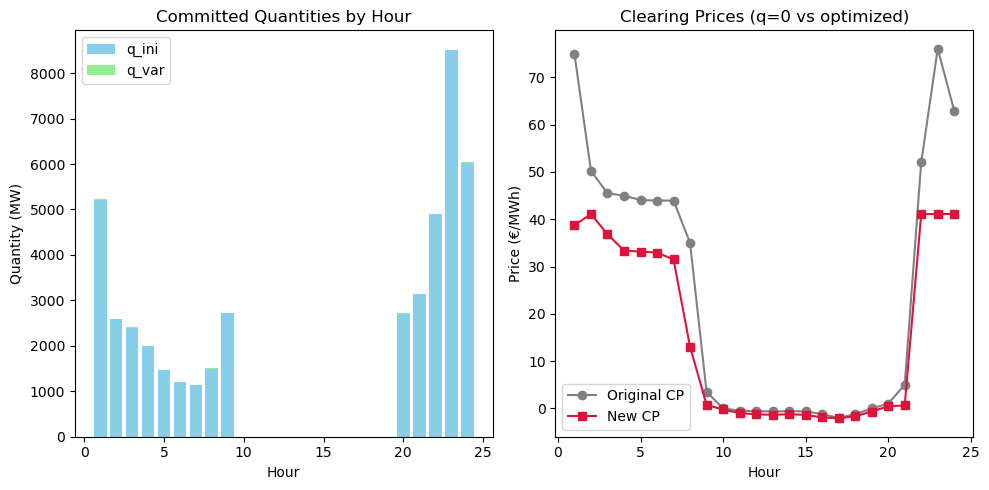

In [78]:

# --- A) 재계산: Supply/Demand 곡선 & original CP ---
price_grid = np.linspace(0, 3000, 500)  # 충분히 넓게 잡으세요
orig_cp = {}
# 미리 곡선 함수 생성
s_funcs = {}
d_funcs = {}
df20 = pd.read_csv("filteredcurve_20250720.csv", encoding="utf-8-sig")
for t in range(1,25):
    sub = df20[df20["Time Period"]==t]
    sup = sub[sub["GC"]=="V"].groupby("Price")["Amount"].sum().reset_index()
    dem = sub[sub["GC"]=="C"].groupby("Price")["Amount"].sum().reset_index()
    if sup.empty or dem.empty:
        continue
    # 누적
    sup = sup.sort_values("Price")
    sup["Cumul"] = sup["Amount"].cumsum()
    dem = dem.sort_values("Price")
    dem["Cumul"] = dem["Amount"][::-1].cumsum()[::-1]
    # 계단 보간
    s_funcs[t] = interp1d(sup["Price"], sup["Cumul"],
                          kind="previous", bounds_error=False,
                          fill_value=(0, sup["Cumul"].iat[-1]))
    d_funcs[t] = interp1d(dem["Price"], dem["Cumul"],
                          kind="previous", bounds_error=False,
                          fill_value=(dem["Cumul"].iat[0], 0))
    # original CP: solve D(p)-S(p)=0
    def resid(p): return d_funcs[t](p) - s_funcs[t](p)
    sol = root_scalar(resid, bracket=[sup["Price"].min(), dem["Price"].max()])
    orig_cp[t] = sol.root if sol.converged else np.nan

# --- B) 결과 데이터 수집 ---
hours   = list(range(1,25))
ini_qty = []
var_qty = []
new_cp  = []
for t in hours:
    # 선택된 block
    b_sel = next((b for b in valid_blocks[t] if u[t,b].X > 0.5), None)
    if b_sel is None:
        ini_qty.append(0)
        var_qty.append(0)
        new_cp .append(np.nan)
    else:
        ini_qty.append(qini20[(t,b_sel)])
        var_qty.append(qvar[t,b_sel].X)
        new_cp .append(lam20 [(t,b_sel)])

orig_cp_list = [orig_cp.get(t, np.nan) for t in hours]

# --- C) 시각화 ---
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# C1) 스택바: initial vs var
ax1 = axes[0]
ax1.bar(hours, ini_qty,     label="q_ini",  color="skyblue")
ax1.bar(hours, var_qty, bottom=ini_qty,
        label="q_var", color="lightgreen")
ax1.set_xlabel("Hour")
ax1.set_ylabel("Quantity (MW)")
ax1.set_title("Committed Quantities by Hour")
ax1.legend()

# C2) 원/신 청산가격 비교
ax2 = axes[1]
ax2.plot(hours, orig_cp_list, 'o-', label="Original CP", color="gray")
ax2.plot(hours, new_cp,      's-', label="New CP",      color="crimson")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Price (€/MWh)")
ax2.set_title("Clearing Prices (q=0 vs optimized)")
ax2.legend()

plt.tight_layout()
plt.show()


### 수리모델링2: offer and operation of WF-ESs

파라메터 설정

In [133]:
# ─────────────────────────────────────────────────────────────
# 5) 모델 파라미터 및 시나리오 생성
# ─────────────────────────────────────────────────────────────

# 시간, 시나리오, 풍력 설비 인덱스
T = list(range(1,25))  # 24시간
S = list(range(10))   # 10개 시나리오
I = list(range(1))    # 1개 풍력 설비

# ESS 파라미터
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500

# # RDC 블록 파라미터
# qini = {(t,b): float(q_breaks[b]) for t in T for b in range(B)}
# qmax = {(t,b): float(delta_qs[b])   for t in T for b in range(B)}

# 풍력 발전량 시나리오 pwf[i,t,s]
np.random.seed(0)
Cw = 1000
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*0.85, Cw*0.20))
    for i in I for t in T for s in S
}

#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
# 시간별 Balancing price
# 15분 단위 RT 가격으로부터 시간별 평균 계산 (shape=(24,))
rt_price_hourly = np.mean(np.array(rt_price_15min).reshape(-1, 4), axis=1)
# rt_price_hourly = rt_price_hourly * 0.6
# Real-Time price 시나리오 생성: t=1→rt_price_hourly[0], …, t=24→rt_price_hourly[23]
np.random.seed(0)
sigma_eta = 0.1
lambda_rt_act = {
    (t, s): rt_price_hourly[t-1] * (1 + sigma_eta * np.random.randn())
    for t in T for s in S
}

# 편차도 마찬가지로 t-1 사용
delta_rt = {
    (t, s): lambda_rt_act[(t,s)] - rt_price_hourly[t-1]
    for t in T for s in S
}

# 시나리오 확률
rho = {s: 1/len(S) for s in S}

코드

In [134]:
pwf_forecast = {
    t: np.mean([ pwf[(0,t,s)] for s in S ])
    for t in T
}

model = gp.Model("WF_ESS_PriceMaker")

# 3-1) Day-Ahead 변수
u    = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    vtype=GRB.BINARY, name="u"
)
qvar = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    lb=0.0, name="qvar"
)


# 3-2) LDR 변수: nominal & slope for DA & RT errors
pc0      = model.addVars(T, lb=0.0, ub=pc_max, name="pc0")
pd0      = model.addVars(T, lb=0.0, ub=pd_max, name="pd0")
# Dpc_da   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpc_da")
Dpc_rt   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpc_rt")
# Dpd_da   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpd_da")
Dpd_rt   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpd_rt")

# 3-3) Recourse 변수
pc = model.addVars(T, S, lb=0.0, ub=pc_max, name="pc")
pd = model.addVars(T, S, lb=0.0, ub=pd_max, name="pd")
E  = model.addVars(T, S, lb=E_min, ub=E_max, name="E")

# 3-4) Binary for charge/discharge
u_c = model.addVars(T, vtype=GRB.BINARY, name="u_c")
u_d = model.addVars(T, vtype=GRB.BINARY, name="u_d")

# 3-5) Objective: DA + expected RT profit
day_ahead = gp.quicksum(
        lam20[(t,b)] * (u[t,b]*qini20[(t,b)] + qvar[t,b])
        for t in T for b in valid_blocks[t])

balancing = gp.quicksum(
    rho[s] * lambda_rt_act[(t,s)] * (
        sum(pwf[(i,t,s)] for i in I)
      + pd[t,s]
      - pc[t,s] #5d
      - sum(u[t,b]*qini20[(t,b)] + qvar[t,b] for b in valid_blocks[t]) #5e
    )
    for t in T for s in S
)
model.setObjective(day_ahead + balancing, GRB.MAXIMIZE)
for t in T:
    model.addConstr(
        gp.quicksum(u[t,b]*qini20[(t,b)] + qvar[t,b]
                    for b in valid_blocks[t])
        <= pwf_forecast[t],
        name=f"DA_commit_le_forecast_{t}"
    )
# 3-6) Constraints
for t in T:
    blks = valid_blocks[t]
    # (2c) 하나의 블록만 선택
    model.addConstr(
        gp.quicksum(u[t,b] for b in blks) == 1,
        name=f"one_block_{t}"
    )
    # (2d) qvar <= qmax * u
    for b in blks:
        model.addConstr(
            qvar[t,b] <= qmax20[(t,b)] * u[t,b],
            name=f"qvar_valid_{t}_{b}"
        )
    # charge/discharge binary
    model.addConstr(u_c[t] + u_d[t] <= 1, name=f"no_simul_binary_{t}") #8b

    for s in S:
        # LDR affine
        model.addConstr(
            pc[t,s] == pc0[t]
                    #   + Dpc_da[t] * delta_da[(t,s)]
                      + Dpc_rt[t] * delta_rt[(t,s)], #7a -> 9
            name=f"LDR_pc_{t}_{s}"
        )
        model.addConstr(
            pd[t,s] == pd0[t]
                    #   + Dpd_da[t] * delta_da[(t,s)]
                      + Dpd_rt[t] * delta_rt[(t,s)], #7b ->10
            name=f"LDR_pd_{t}_{s}"
        )
        # Big-M for pc/pd
        model.addConstr(pc[t,s] <= pc_max * u_c[t],
                        name=f"pc_bigm_{t}_{s}") #7a -> 9
        model.addConstr(pd[t,s] <= pd_max * u_d[t],
                        name=f"pd_bigm_{t}_{s}") #7b ->10
        # SOC dynamics 7c
        if t == 1: 
            model.addConstr(
                E[t,s] == E0 + eta_c*pc[t,s] - pd[t,s]/eta_d,
                name=f"SOC_init_{t}_{s}"
            )
        else:
            model.addConstr(
                E[t,s] == E[t-1,s] + eta_c*pc[t,s] - pd[t,s]/eta_d,
                name=f"SOC_trans_{t}_{s}"
            )

# time limit & optimize
model.Params.TimeLimit = 60
model.optimize()

Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 97248 rows, 192816 columns and 483234 nonzeros
Model fingerprint: 0x21682800
Variable types: 96792 continuous, 96024 integer (96024 binary)
Coefficient statistics:
  Matrix range     [2e-05, 2e+04]
  Objective range  [4e-05, 2e+06]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 94846 rows and 189427 columns
Presolve time: 0.03s
Presolved: 2402 rows, 3389 columns, 9606 nonzeros
Variable types: 1976 continuous, 1413 integer (1413 binary)
Found heuristic solution: objective 560261.15738

Root relaxation: objective 7.277823e+05, 281 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl U

In [127]:
valid_blocks = {
    t: [ b 
         for (tt,b), dq in qmax20.items() 
         if tt == t and dq > 0 ]
    for t in T
}

pwf보다 작아야한다는 제약식 없는 버전

In [ ]:
model = gp.Model("WF_ESS_PriceMaker")

# 3-1) Day-Ahead 변수
u    = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    vtype=GRB.BINARY, name="u"
)
qvar = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    lb=0.0, name="qvar"
)


# 3-2) LDR 변수: nominal & slope for DA & RT errors
pc0      = model.addVars(T, lb=0.0, ub=pc_max, name="pc0")
pd0      = model.addVars(T, lb=0.0, ub=pd_max, name="pd0")
# Dpc_da   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpc_da")
Dpc_rt   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpc_rt")
# Dpd_da   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpd_da")
Dpd_rt   = model.addVars(T, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Dpd_rt")

# 3-3) Recourse 변수
pc = model.addVars(T, S, lb=0.0, ub=pc_max, name="pc")
pd = model.addVars(T, S, lb=0.0, ub=pd_max, name="pd")
E  = model.addVars(T, S, lb=E_min, ub=E_max, name="E")

# 3-4) Binary for charge/discharge
u_c = model.addVars(T, vtype=GRB.BINARY, name="u_c")
u_d = model.addVars(T, vtype=GRB.BINARY, name="u_d")

# 3-5) Objective: DA + expected RT profit
day_ahead = gp.quicksum(
        lam20[(t,b)] * (u[t,b]*qini20[(t,b)] + qvar[t,b])
        for t in T for b in valid_blocks[t])

balancing = gp.quicksum(
    rho[s] * lambda_rt_act[(t,s)] * (
        sum(pwf[(i,t,s)] for i in I)
      + pd[t,s]
      - pc[t,s] #5d
      - sum(u[t,b]*qini20[(t,b)] + qvar[t,b] for b in valid_blocks[t]) #5e
    )
    for t in T for s in S
)
model.setObjective(day_ahead + balancing, GRB.MAXIMIZE)

# 3-6) Constraints
for t in T:
    blks = valid_blocks[t]
    # (1c) 하나의 블록만 선택
    model.addConstr(
        gp.quicksum(u[t,b] for b in blks) == 1,
        name=f"one_block_{t}"
    )
    # (1d) qvar <= qmax * u
    for b in blks:
        model.addConstr(
            qvar[t,b] <= qmax20[(t,b)] * u[t,b],
            name=f"qvar_valid_{t}_{b}"
        )
    # (1k) charge/discharge binary
    model.addConstr(u_c[t] + u_d[t] <= 1, name=f"no_simul_binary_{t}") 

    for s in S:
        # (1h) LDR affine
        model.addConstr(
            pc[t,s] == pc0[t]
                    #   + Dpc_da[t] * delta_da[(t,s)]
                      + Dpc_rt[t] * delta_rt[(t,s)], 
            name=f"LDR_pc_{t}_{s}"
        )
        # (1i)
        model.addConstr(
            pd[t,s] == pd0[t]
                    #   + Dpd_da[t] * delta_da[(t,s)]
                      + Dpd_rt[t] * delta_rt[(t,s)],
            name=f"LDR_pd_{t}_{s}"
        )
        # Big-M for pc/pd
        # 
        model.addConstr(pc[t,s] <= pc_max * u_c[t],
                        name=f"pc_bigm_{t}_{s}") 
        model.addConstr(pd[t,s] <= pd_max * u_d[t],
                        name=f"pd_bigm_{t}_{s}") 
        # SOC dynamics 7c
        # (1j)
        if t == 1: 
            model.addConstr(
                E[t,s] == E0 + eta_c*pc[t,s] - pd[t,s]/eta_d,
                name=f"SOC_init_{t}_{s}"
            )
        else:
            model.addConstr(
                E[t,s] == E[t-1,s] + eta_c*pc[t,s] - pd[t,s]/eta_d,
                name=f"SOC_trans_{t}_{s}"
            )

# time limit & optimize
model.Params.TimeLimit = 60
model.optimize()

Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 97248 rows, 192816 columns and 483234 nonzeros
Model fingerprint: 0x9920c18d
Variable types: 96792 continuous, 96024 integer (96024 binary)
Coefficient statistics:
  Matrix range     [1e-05, 2e+04]
  Objective range  [4e-05, 1e+06]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 93869 rows and 187592 columns
Presolve time: 0.03s
Presolved: 3379 rows, 5224 columns, 14238 nonzeros
Variable types: 2943 continuous, 2281 integer (2281 binary)
Found heuristic solution: objective 474533.60666

Root relaxation: objective 5.750463e+05, 288 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl 

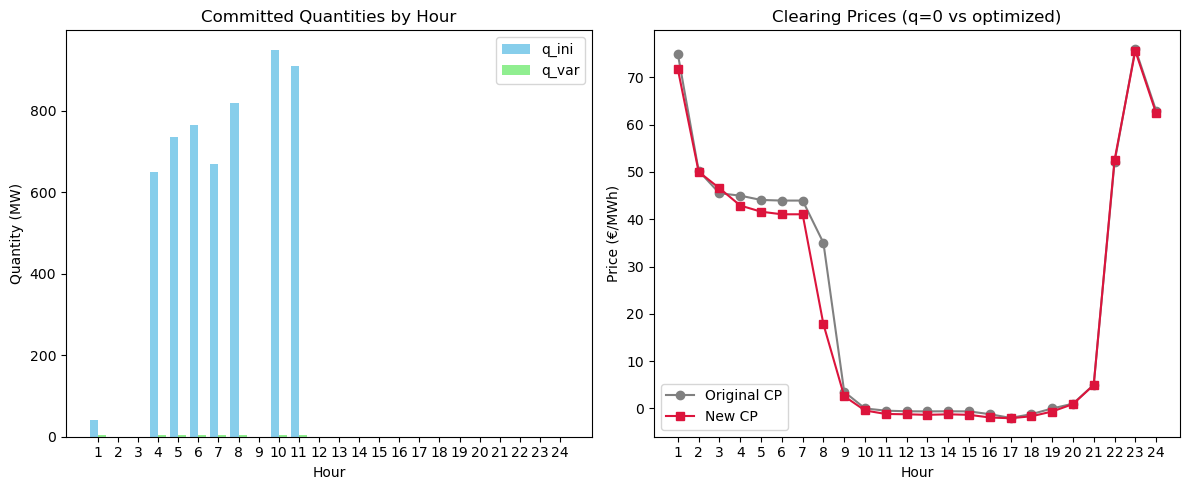

In [130]:
# --- 1) 최적화 완료 직후, 결과 추출 ---
hours      = T  # 1~24
q_ini_res  = []
q_var_res  = []
orig_price = []
new_price  = []
date_str = '20250720'  # 예시 날짜
for t in hours:
    # 선택된 block b 찾아서
    for b in valid_blocks[t]:
        if u[t,b].X > 0.5:
            q_ini_res.append(qini20[(t,b)])     # DA commit initial
            q_var_res.append(qvar[t,b].X)       # DA commit 추가량
            orig_price.append(orig_cp[(date_str, t)])  # q=0 clearing price
            new_price.append(lam20[(t,b)])      # 최적화된 DA price
            break

# --- 2) 시각화 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# 2-1) Committed Quantities by Hour
x = np.array(hours)
ax1.bar(x-0.2, q_ini_res, width=0.4, label='q_ini', color='skyblue')
ax1.bar(x+0.2, q_var_res, width=0.4, label='q_var', color='lightgreen')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Quantity (MW)')
ax1.set_title('Committed Quantities by Hour')
ax1.set_xticks(hours)
ax1.legend()

# 2-2) Clearing Prices 비교
ax2.plot(x, orig_price,    '-o', color='gray',   label='Original CP')
ax2.plot(x, new_price,     '-s', color='crimson', label='New CP')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Price (€/MWh)')
ax2.set_title('Clearing Prices (q=0 vs optimized)')
ax2.set_xticks(hours)
ax2.legend()

plt.tight_layout()
plt.show()


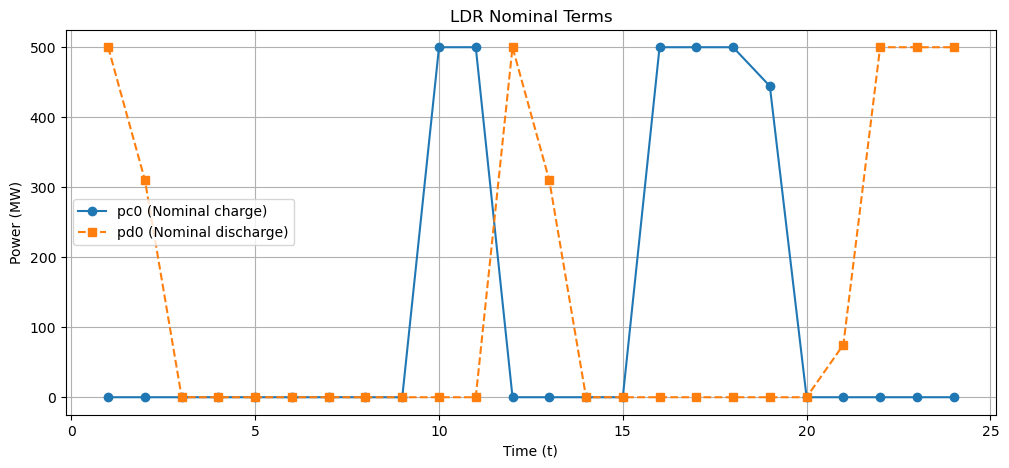

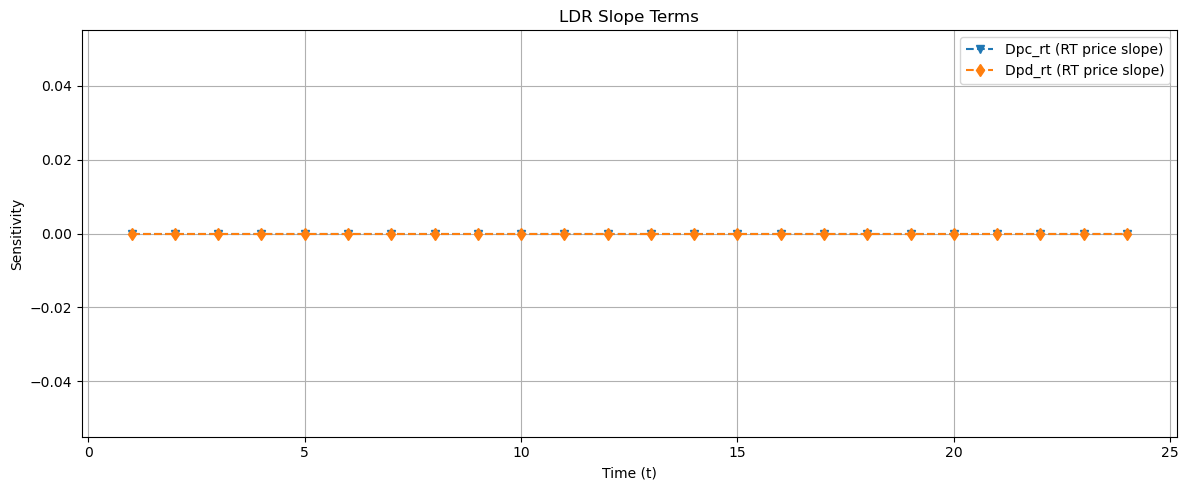

In [124]:
# ─────────────────────────────────────────────────────────────
# 7) 결과 시각화 (LDR 파라미터)
# ─────────────────────────────────────────────────────────────
# extract LDR terms
pc0_vals = [pc0[t].X for t in T]
pd0_vals = [pd0[t].X for t in T]
Dpc_rt_vals = [Dpc_rt[t].X for t in T]
Dpd_rt_vals = [Dpd_rt[t].X for t in T]

# plot nominal terms
plt.figure(figsize=(12,5))
plt.plot(T, pc0_vals, 'o-', label='pc0 (Nominal charge)')
plt.plot(T, pd0_vals, 's--', label='pd0 (Nominal discharge)')
plt.title("LDR Nominal Terms")
plt.xlabel("Time (t)"); plt.ylabel("Power (MW)")
plt.legend(); plt.grid(True)

# plot slopes
plt.figure(figsize=(12,5))
plt.plot(T, Dpc_rt_vals, 'v--', label='Dpc_rt (RT price slope)')
plt.plot(T, Dpd_rt_vals, 'd--', label='Dpd_rt (RT price slope)')
plt.title("LDR Slope Terms")
plt.xlabel("Time (t)"); plt.ylabel("Sensitivity")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

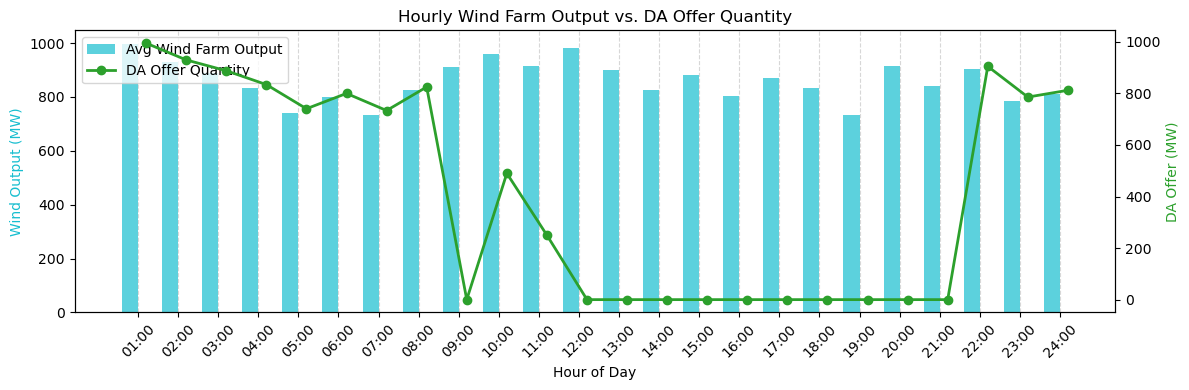

In [125]:
# ─────────────────────────────────────────────────────────────
# 1) 시간당 평균 풍력 발전량 계산
# ─────────────────────────────────────────────────────────────
# rho[s] 는 시나리오 확률, I = [0] 이므로 아래는 간단히 시나리오 평균만
pwf_bar = []
for t in T:
    # 시나리오별 풍력량을 확률로 가중합
    mean_wind = sum(rho[s]*pwf[(0,t,s)] for s in S)
    pwf_bar.append(mean_wind)

# ─────────────────────────────────────────────────────────────
# 2) DA 오퍼량 q_DA[t] 계산 (이미 구하셨다면 이 부분은 생략하셔도 됩니다)
# ─────────────────────────────────────────────────────────────
q_DA = []
for t in T:
    qt = sum(u[t,b].X * qini20[(t,b)] + qvar[t,b].X for b in range(B))
    q_DA.append(qt)

# ─────────────────────────────────────────────────────────────
# 3) 시각화: 풍력 vs. DA 오퍼량
# ─────────────────────────────────────────────────────────────
hours = np.array(T)
labels = [f"{h:02d}:00" for h in T]

fig, ax1 = plt.subplots(figsize=(12,4))
ax2 = ax1.twinx()

# 풍력(바)
ax1.bar(hours-0.2, pwf_bar, width=0.4, color='tab:cyan', alpha=0.7, label='Avg Wind Farm Output')
# DA 오퍼량(선)
ax2.plot(hours+0.2, q_DA, 'o-', color='tab:green', lw=2, label='DA Offer Quantity')

# 축 레이블 & 타이틀
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Wind Output (MW)", color='tab:cyan')
ax2.set_ylabel("DA Offer (MW)",   color='tab:green')
ax1.set_xticks(hours)
ax1.set_xticklabels(labels, rotation=45)
ax1.set_title("Hourly Wind Farm Output vs. DA Offer Quantity")

# 범례 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')

ax1.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 수리모델링3: RDC에 대한 시나리오를 고려해서

In [10]:
# 1) 날짜 리스트와 시나리오 인덱스 정의
date_range = [f"202507{d:02d}" for d in range(20, 28)]  # 20~27일
S = list(range(len(date_range)))                      # 0~7

# 2) qini, qmax, lambda_da_block 에서
#    날짜별로 꺼내서 (s,t,b) 키로 합치기
qini_scen  = {}
qmax_scen  = {}
lambda_da_scen = {}

for s, date in enumerate(date_range):
    # qini
    qini_scen.update({
        (s, t, b): q
        for (d, t, b), q in qini.items()
        if d == date
    })
    # qmax
    qmax_scen.update({
        (s, t, b): Δ
        for (d, t, b), Δ in qmax.items()
        if d == date
    })
    # lambda_da_block
    lambda_da_scen.update({
        (s, t, b): π
        for (d, t, b), π in lambda_da_block.items()
        if d == date
    })


In [13]:
valid_blocks = {
    t: sorted({
        b
        for (s2, tt, b), Δ in qmax_scen.items()
        if tt == t and Δ > 0
    })
    for t in T
}

In [17]:
# 1) 날짜 및 시나리오 정의
# date_range = [f"202507{d:02d}" for d in range(20, 28)]  # 20,21,…,27
T = list(range(1, 25))                                # 시간 1~24
I = list(range(1))                                     # 풍력 설비 0번만

# 시나리오 확률 (균등)
rho = {s: 1/len(S) for s in S}

# 2) ESS 파라미터
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500

# 3) RDC 시나리오 생성: qini_scen[(s,t,b)], qmax_scen[(s,t,b)], lambda_da_scen[(s,t,b)]


# 4) PWf 및 RT 가격 평균값 계산 (Deterministic)
# 4-1) 풍력 시나리오(10개) 생성 → 평균
Sw = list(range(10))
np.random.seed(0)
Cw = 1000
pwf_samples = {
    (i, t, sample): max(0, np.random.normal(Cw*0.85, Cw*0.20))
    for i in I for t in T for sample in Sw
}
pwf_forecast = {
    t: np.mean([ pwf_samples[(0, t, s)] for s in Sw ])
    for t in T
}

# 4-2) 실시간 15분단위 가격(20일) → 시간별 평균
rt_price_15min = [
    75.78,75.54,72.72,42.23,75.30,75.30,61.91,35.25,75.30,48.33,
    39.81,23.08,65.80,49.92,33.81,18.07,45.68,35.81,26.04,30.98,
    32.11,36.47,34.14,29.49,27.58,34.34,21.44,33.44,26.00, 3.30,
    -1.99,-8.99,28.79, 0.49,-5.51,-6.31, 3.52, 0.65,-1.01,-5.90,
    -0.97,-3.00,-3.00, 0.00, 0.01, 4.31, 0.00, 0.00, 0.99, 0.99,
     0.14, 0.00, 0.65, 0.65, 0.65, 0.00, 0.99, 0.00, 0.00, 0.00,
    -0.65,-0.65,-0.50,-0.65, 0.00, 0.00, 0.00,-0.01,-0.61, 0.00,
     0.00, 0.00, 0.00, 0.00, 0.00, 0.00,-9.70,-0.97,20.33,79.89,
    -8.99, 8.81,49.88,83.87,36.84,66.60,72.19,75.54,82.80,82.80,
    85.21,82.01,86.16,78.72,72.27,53.31
]
rt_price_hourly = np.mean(np.array(rt_price_15min).reshape(-1,4), axis=1)
lambda_rt_avg = { t: rt_price_hourly[t-1] for t in T }

# 5) 모델 작성
model = gp.Model("WF_ESS_RDC_Scenarios")

# 5-1) Stage-1 결정변수: 블록 선택 & 추가량
u    = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    vtype=GRB.BINARY, name="u"
)
qvar = model.addVars(
    [(t,b) for t in T for b in valid_blocks[t]],
    lb=0.0, name="qvar"
)

# 5-2) Recourse 결정변수: 충·방전량, SOC, 이진
pc  = model.addVars(
    [(t,s) for t in T for s in S],
    lb=0.0, ub=pc_max, name="pc"
)
pd  = model.addVars(
    [(t,s) for t in T for s in S],
    lb=0.0, ub=pd_max, name="pd"
)
E   = model.addVars(
    [(t,s) for t in T for s in S],
    lb=E_min, ub=E_max, name="E"
)
u_c = model.addVars(T, vtype=GRB.BINARY, name="u_c")
u_d = model.addVars(T, vtype=GRB.BINARY, name="u_d")

# 5-3) 목적함수: 기대 DA 수익 + 기대 RT 수익
day_ahead = gp.quicksum(
    rho[s] *
    lambda_da_scen[(s,t,b)] *
    (u[t,b]*qini_scen[(s,t,b)] + qvar[t,b])
    for s in S for t in T for b in valid_blocks[t]
)
balancing = gp.quicksum(
    rho[s] * lambda_rt_avg[t] * (
        pwf_forecast[t]
      + pd[t,s]
      - pc[t,s]
      - gp.quicksum(u[t,b]*qini_scen[(s,t,b)] + qvar[t,b]
                    for b in valid_blocks[t])
    )
    for s in S for t in T
)
model.setObjective(day_ahead + balancing, GRB.MAXIMIZE)

# 5-4) 제약식
for t in T:
    # (DA-1) 하나의 블록만 선택
    model.addConstr(
        gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
        name=f"one_block_{t}"
    )

    # (DA-2) qvar는 모든 시나리오에서 유효해야 함 → worst-case qmax
    for b in valid_blocks[t]:
        for s in S:
            model.addConstr(
                qvar[t,b] <= qmax_scen[(s,t,b)] * u[t,b],
                name=f"qvar_valid_{t}_{b}_{s}"
            )

    # (DA-3) 약속량 ≤ 예측 풍력 (시나리오별)
    for s in S:
        model.addConstr(
            gp.quicksum(
                u[t,b] * qini_scen[(s,t,b)]
                + qvar[t,b]
                for b in valid_blocks[t]
            )
            <= pwf_forecast[t],
            name=f"commit_le_forecast_{t}_{s}"
        )

    # (ESS-1) 충·방전 동시 금지
    model.addConstr(
        u_c[t] + u_d[t] <= 1,
        name=f"no_simul_{t}"
    )

    # (ESS-2) Big-M 제약 및 (ESS-3) SOC 초기·전이
    for s in S:
        model.addConstr(pc[t,s] <= pc_max * u_c[t],
                        name=f"pc_bigm_{t}_{s}")
        model.addConstr(pd[t,s] <= pd_max * u_d[t],
                        name=f"pd_bigm_{t}_{s}")
        if t == 1:
            model.addConstr(
                E[t,s] == E0 + eta_c*pc[t,s] - pd[t,s]/eta_d,
                name=f"SOC_init_{t}_{s}"
            )
        else:
            model.addConstr(
                E[t,s] == E[t-1,s] + eta_c*pc[t,s] - pd[t,s]/eta_d,
                name=f"SOC_trans_{t}_{s}"
            )


# 6) 해석 조건 설정 & 최적화
model.Params.TimeLimit = 60
model.optimize()

# 결과 예시 출력
if model.status == GRB.OPTIMAL:
    print("Objective:", model.ObjVal)
    for t in T:
        for b in valid_blocks[t]:
            if u[t,b].X > 0.5:
                print(f"Hour {t}, select block {b}, qvar = {qvar[t,b].X:.2f}")

Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 768624 rows, 192576 columns and 3168592 nonzeros
Model fingerprint: 0xd9675f95
Variable types: 96552 continuous, 96024 integer (96024 binary)
Coefficient statistics:
  Matrix range     [9e-01, 2e+04]
  Objective range  [8e-05, 2e+06]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Found heuristic solution: objective 689152.80613
Presolve removed 737434 rows and 184334 columns
Presolve time: 0.16s
Presolved: 31190 rows, 8242 columns, 126947 nonzeros
Found heuristic solution: objective 695595.75104
Variable types: 4375 continuous, 3867 integer (3867 binary)
Found heuristic solution: objective 972765.02135

Root relaxation: objective 9.829136e+05, 1 iterations, 0.00 secon

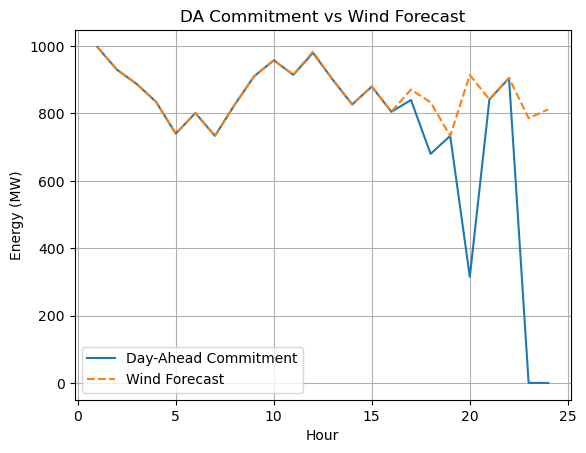

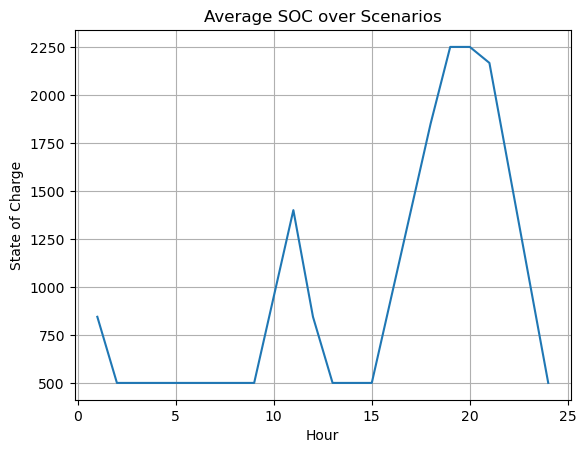

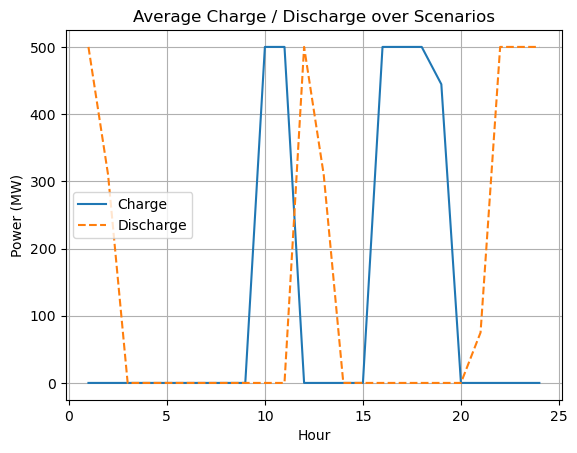

In [18]:
# import matplotlib.pyplot as plt

# 1) 시간 리스트
hours = sorted(T)

# 2) DA Commitment vs Wind Forecast (scenario 0 기준)
committed = []
for t in hours:
    # 선택된 블록 인덱스 찾기
    b_star = next(b for b in valid_blocks[t] if u[t, b].X > 0.5)
    # commitment = qini + qvar
    committed.append(qini_scen[(0, t, b_star)] + qvar[t, b_star].X)

forecast = [pwf_forecast[t] for t in hours]

plt.figure()
plt.plot(hours, committed, label='Day-Ahead Commitment')
plt.plot(hours, forecast, linestyle='--', label='Wind Forecast')
plt.xlabel('Hour')
plt.ylabel('Energy (MW)')
plt.title('DA Commitment vs Wind Forecast')
plt.legend()
plt.grid(True)
plt.show()


# 3) Average SOC across scenarios
soc_avg = [sum(E[t, s].X for s in S) / len(S) for t in hours]

plt.figure()
plt.plot(hours, soc_avg)
plt.xlabel('Hour')
plt.ylabel('State of Charge')
plt.title('Average SOC over Scenarios')
plt.grid(True)
plt.show()


# 4) Average Charge / Discharge
pc_avg = [sum(pc[t, s].X for s in S) / len(S) for t in hours]
pd_avg = [sum(pd[t, s].X for s in S) / len(S) for t in hours]

plt.figure()
plt.plot(hours, pc_avg, label='Charge')
plt.plot(hours, pd_avg, linestyle='--', label='Discharge')
plt.xlabel('Hour')
plt.ylabel('Power (MW)')
plt.title('Average Charge / Discharge over Scenarios')
plt.legend()
plt.grid(True)
plt.show()


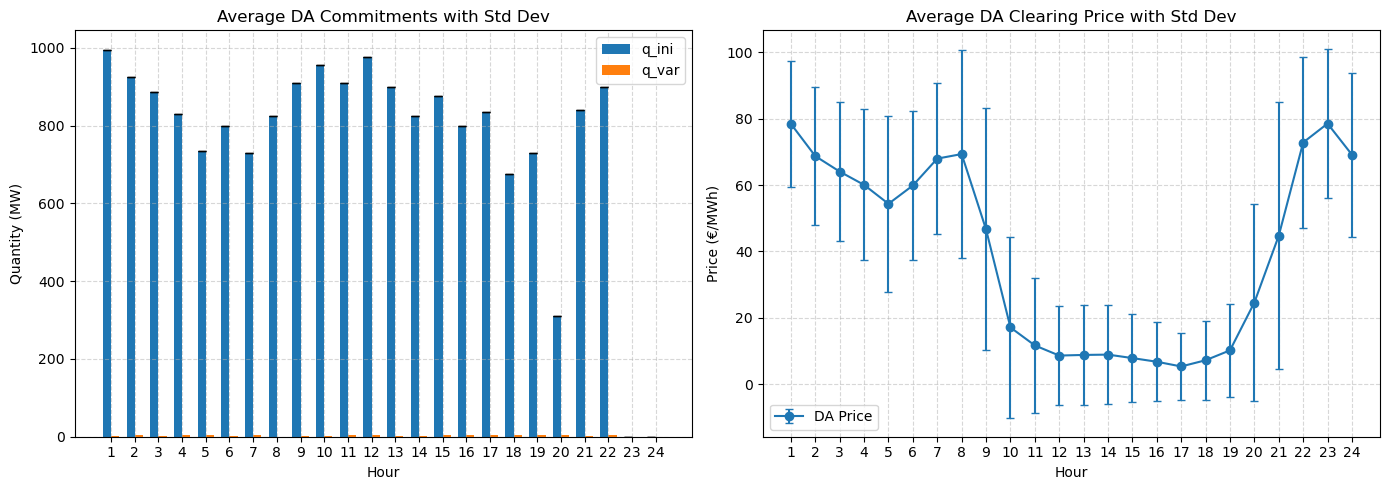

In [21]:

# 1) 시간 리스트
hours = sorted(T)
num_hours = len(hours)
num_scenarios = len(S)

# 2) Q_ini 및 Q_var: 평균과 표준편차 계산
q_ini_vals = np.zeros((num_scenarios, num_hours))
q_var_vals = np.zeros((num_hours,))  # qvar은 시나리오 무관

for s in S:
    for i, t in enumerate(hours):
        b_star = next(b for b in valid_blocks[t] if u[t, b].X > 0.5)
        q_ini_vals[s, i] = qini_scen[(s, t, b_star)]
        if s == 0:
            q_var_vals[i] = qvar[t, b_star].X

q_ini_mean = q_ini_vals.mean(axis=0)
q_ini_std  = q_ini_vals.std(axis=0)

# 3) DA 가격: 평균과 표준편차 계산
price_vals = np.zeros((num_scenarios, num_hours))
for s in S:
    for i, t in enumerate(hours):
        b_star = next(b for b in valid_blocks[t] if u[t, b].X > 0.5)
        price_vals[s, i] = lambda_da_scen[(s, t, b_star)]

price_mean = price_vals.mean(axis=0)
price_std  = price_vals.std(axis=0)

# 4) 시각화: 1×2 레이아웃
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 4-1) Commitments: errorbar 포함 바차트
x = np.arange(num_hours) + 1
width = 0.35

ax1.bar(x - width/2, q_ini_mean, width, yerr=q_ini_std, capsize=3, label='q_ini')
ax1.bar(x + width/2, q_var_vals, width, label='q_var')

ax1.set_xlabel('Hour')
ax1.set_ylabel('Quantity (MW)')
ax1.set_title('Average DA Commitments with Std Dev')
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# 4-2) DA Prices: errorbar 라인플롯
ax2.errorbar(x, price_mean, yerr=price_std, fmt='-o', capsize=3, label='DA Price')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Price (€/MWh)')
ax2.set_title('Average DA Clearing Price with Std Dev')
ax2.set_xticks(x)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [23]:

# ───────────────────────────────────────────────────────────────
# 0) (사전 정의) 아래 사전(dict)들이 메모리에 로드되어 있어야 합니다.
#    • qini[(date, t, b)], qmax[(date, t, b)], lambda_da_block[(date, t, b)]
#    • orig_cp[(date, t)] : q=0 일 때 clearing price
# ───────────────────────────────────────────────────────────────

# 1) 날짜 및 인덱스 정의
date_range = [f"202507{d:02d}" for d in range(20, 28)]  # 20~27
T = list(range(1, 25))                                 # 시간 1~24
S = list(range(len(date_range)))                       # 시나리오 0~7
I = [0]                                                # 풍력 설비 하나
rho = {s: 1/len(S) for s in S}                         # 균등 확률

# 2) ESS 파라미터 (Here-and-Now)
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500

# 3) RDC 시나리오 파라미터 맵 생성 (Recourse)
qini_scen      = {}
qmax_scen      = {}
lambda_da_scen = {}
for s, date in enumerate(date_range):
    # qini, qmax, lambda_da_block 에서 날짜별 필터
    qini_scen.update({
        (s,t,b): q
        for (d,t,b), q in qini.items() if d==date
    })
    qmax_scen.update({
        (s,t,b): Δ
        for (d,t,b), Δ in qmax.items() if d==date
    })
    lambda_da_scen.update({
        (s,t,b): π
        for (d,t,b), π in lambda_da_block.items() if d==date
    })

# 유효 블록 리스트: "어느 시나리오 한 곳이라도 qmax>0"인 블록만
valid_blocks = {
    t: sorted({ b for (s2,tt,b),Δ in qmax_scen.items() if tt==t and Δ>0 })
    for t in T
}

# 4) 풍력 / RT 가격 (Deterministic)
# 4-1) 풍력 예측량: 10개 샘플 평균
Sw = list(range(10))
np.random.seed(0)
Cw=1000
pwf_samples = {
    (i,t,samp): max(0,np.random.normal(Cw*0.85, Cw*0.20))
    for i in I for t in T for samp in Sw
}
pwf_forecast = { t: np.mean([pwf_samples[(0,t,s)] for s in Sw]) for t in T }

# 4-2) RT 가격: 15분 단위 → 시간별 평균
rt15 = [75.78,75.54,72.72,42.23,75.30,75.30,61.91,35.25,75.30,48.33,
        39.81,23.08,65.80,49.92,33.81,18.07,45.68,35.81,26.04,30.98,
        32.11,36.47,34.14,29.49,27.58,34.34,21.44,33.44,26.00, 3.30,
        -1.99,-8.99,28.79, 0.49,-5.51,-6.31, 3.52, 0.65,-1.01,-5.90,
        -0.97,-3.00,-3.00, 0.00, 0.01, 4.31, 0.00, 0.00, 0.99, 0.99,
         0.14, 0.00, 0.65, 0.65, 0.65, 0.00, 0.99, 0.00, 0.00, 0.00,
        -0.65,-0.65,-0.50,-0.65, 0.00, 0.00, 0.00,-0.01,-0.61, 0.00,
         0.00, 0.00, 0.00, 0.00, 0.00, 0.00,-9.70,-0.97,20.33,79.89,
        -8.99, 8.81,49.88,83.87,36.84,66.60,72.19,75.54,82.80,82.80,
        85.21,82.01,86.16,78.72,72.27,53.31 ]
rt_hourly = np.mean(np.array(rt15).reshape(-1,4),axis=1)
lambda_rt_avg = { t: rt_hourly[t-1] for t in T }

# 5) 모델 생성
model = gp.Model("WF_ESS_RDC_Recourse")

# 5-1) Here-and-Now: ESS 변수
u_c = model.addVars(T, vtype=GRB.BINARY, name="u_c")
u_d = model.addVars(T, vtype=GRB.BINARY, name="u_d")
pc  = model.addVars(T, lb=0, ub=pc_max, name="pc")
pd  = model.addVars(T, lb=0, ub=pd_max, name="pd")
E   = model.addVars(T, lb=E_min, ub=E_max, name="E")

# 5-2) Recourse: 블록선택 & qvar
u    = model.addVars(
    [(t,b,s) for t in T for b in valid_blocks[t] for s in S],
    vtype=GRB.BINARY, name="u"
)

qvar = model.addVars(
    [(t,b,s) for t in T for b in valid_blocks[t] for s in S],
    lb=0.0, name="qvar"
)

# 5-3) 목적함수
day_ahead = gp.quicksum(
    rho[s] *
    lambda_da_scen[(s,t,b)] *
    (u[t,b,s]*qini_scen[(s,t,b)] + qvar[t,b,s])
    for s in S for t in T for b in valid_blocks[t]
)
balancing = gp.quicksum(
    rho[s] *
    lambda_rt_avg[t] * (
        pwf_forecast[t]
      + pd[t]
      - pc[t]
      - gp.quicksum(u[t,b,s]*qini_scen[(s,t,b)] + qvar[t,b,s]
                    for b in valid_blocks[t])
    )
    for s in S for t in T
)
model.setObjective(day_ahead + balancing, GRB.MAXIMIZE)

# 5-4) 제약식
for t in T:
    # ESS 동시충·방전 금지
    model.addConstr(u_c[t] + u_d[t] <= 1, name=f"no_simul_{t}")
    # Big-M for ESS
    model.addConstr(pc[t] <= pc_max * u_c[t], name=f"pc_bigm_{t}")
    model.addConstr(pd[t] <= pd_max * u_d[t], name=f"pd_bigm_{t}")
    # SOC
    if t==1:
        model.addConstr(E[t] == E0 + eta_c*pc[t] - pd[t]/eta_d,
                        name=f"SOC_init_{t}")
    else:
        model.addConstr(E[t] == E[t-1] + eta_c*pc[t] - pd[t]/eta_d,
                        name=f"SOC_trans_{t}")

    # Recourse: 블록선택 & qvar
    for s in S:
        # 하나의 블록만
        model.addConstr(gp.quicksum(u[t,b,s] for b in valid_blocks[t])==1,
                        name=f"one_block_{t}_{s}")
        # qvar ≤ qmax
        for b in valid_blocks[t]:
            model.addConstr(qvar[t,b,s] <= qmax_scen[(s,t,b)]*u[t,b,s],
                            name=f"qvar_valid_{t}_{b}_{s}")
        # 커밋량 ≤ 풍력예측
        model.addConstr(
            gp.quicksum(u[t,b,s]*qini_scen[(s,t,b)] + qvar[t,b,s]
                        for b in valid_blocks[t])
            <= pwf_forecast[t],
            name=f"commit_le_forecast_{t}_{s}"
        )

# 6) 최적화
model.Params.TimeLimit = 60
model.optimize()

Set parameter TimeLimit to value 60
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 768288 rows, 1535736 columns and 3839087 nonzeros
Model fingerprint: 0x8b0aa4c7
Variable types: 767880 continuous, 767856 integer (767856 binary)
Coefficient statistics:
  Matrix range     [9e-01, 2e+04]
  Objective range  [2e-06, 2e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Found heuristic solution: objective 689451.88472
Presolve removed 745474 rows and 1489611 columns
Presolve time: 0.28s
Presolved: 22814 rows, 46125 columns, 114556 nonzeros
Found heuristic solution: objective 726165.53015
Variable types: 22516 continuous, 23609 integer (23609 binary)
Found heuristic solution: objective 1035943.1420

Root relaxation: objective 1.036098e+06, 1 iterations, 0

ValueError: List of boxplot statistics and `positions` values must have same the length

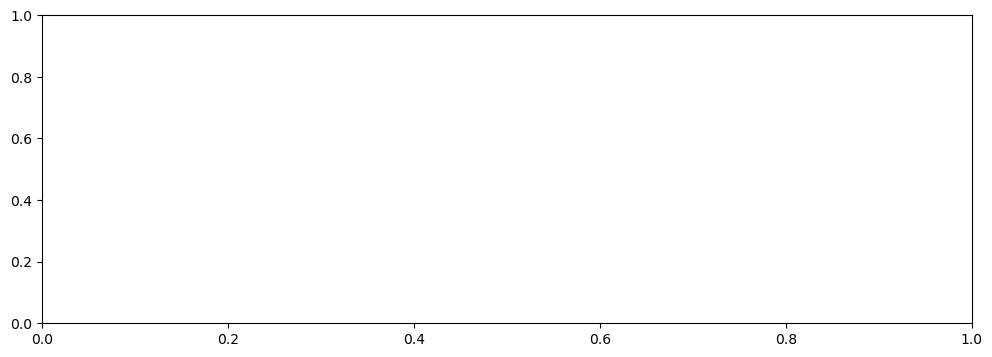

In [29]:
# import numpy as np
# import matplotlib.pyplot as plt

# 1) 시간 리스트 원본
hours_full = sorted(T)         # 예: [1,2,…,24]
num_scen   = len(S)

# 2) comm, price 배열 생성
#   comm.shape = (num_scen, num_t)
#   price.shape = (num_scen, num_t)
comm  = []
price = []
for s in S:
    comm_s  = []
    price_s = []
    for t in hours_full:
        # 해당 시나리오 s, 시간 t에서 선택된 블록 찾기
        b_star = next(b for b in valid_blocks[t] if u[t,b,s].X > 0.5)
        # DA commit
        comm_s.append(qini_scen[(s,t,b_star)] + qvar[t,b_star,s].X)
        # DA clearing price
        price_s.append(lambda_da_scen[(s,t,b_star)])
    comm.append(comm_s)
    price.append(price_s)

comm  = np.array(comm)   # shape (S, H)
price = np.array(price)  # shape (S, H)

# 3) 실제 플롯할 시간 축 길이를 comm.shape[1] 에 맞춤
num_t     = comm.shape[1]      # 실제 시간 수 (보통 24)
positions = np.arange(1, num_t+1)
hours     = hours_full[:num_t] # comm 열 개수만큼 자르기

# --- (1) DA Commit 분포: 박스플롯 ---
plt.figure(figsize=(12,4))
plt.boxplot(comm.T,
            positions=positions,
            showfliers=False)
plt.xticks(positions, hours) 
plt.xlabel('Hour')
plt.ylabel('Committed Quantity (MW)')
plt.title('Distribution of DA Commitments across Scenarios')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- (2) DA Price 분포: 박스플롯 ---
plt.figure(figsize=(12,4))
plt.boxplot(price.T,
            positions=positions,
            showfliers=False)
plt.xticks(positions, hours)
plt.xlabel('Hour')
plt.ylabel('DA Clearing Price (€/MWh)')
plt.title('Distribution of DA Prices across Scenarios')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- (3) ESS Schedule & SOC: 선그래프 ---
charge   = [pc[t].X for t in hours]
discharge= [pd[t].X for t in hours]
soc      = [E[t].X  for t in hours]

fig, axes = plt.subplots(1, 2, figsize=(14,4))
axes[0].plot(hours, charge,   '-o', label='Charge')
axes[0].plot(hours, discharge,'-s', label='Discharge')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Power (MW)')
axes[0].set_title('ESS Charge/Discharge Schedule')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(hours, soc, '-^')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('State of Charge (MWh)')
axes[1].set_title('ESS State of Charge')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
